# HW12: Временные ряды, temporal split, baseline-модели и GRU-прогноз

В этом ноутбуке выполняется домашнее задание к семинару 12.
Реализованы:
1. Загрузка и анализ данных.
2. Корректный temporal split.
3. Построение признаков (lag, rolling, calendar).
4. Эксперименты: B1 (naive), B2 (moving average), B3 (Ridge), R1 (GRU).
5. Сохранение артефактов и отчётность.

In [49]:
# 1. Импорты, seed и среда
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Настройки
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

# Фиксация семян для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# создание необходимых папок для артефактов

BASE_DIR = Path('.')
ARTIFACTS_DIR = BASE_DIR / 'artifacts'
FIGURES_DIR = ARTIFACTS_DIR / 'figures'

# Создание папок (exist_ok=True предотвращает ошибку, если папка уже существует)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Проверка создания
print("создание необходимых папок для артефактов")
print(f"Base directory: {BASE_DIR.resolve()}")
print(f"Artifacts directory: {ARTIFACTS_DIR.resolve()}")
print(f"Figures directory: {FIGURES_DIR.resolve()}")
print(f"{'='*60}\n")

# Пути к файлам
DATASET_PATH = BASE_DIR / 'S12-hw-dataset.csv'

# Проверка наличия датасета
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Файл {DATASET_PATH} не найден!\n"
        f"Положите S12-hw-dataset.csv в папку с ноутбуком:\n"
        f"  {DATASET_PATH.resolve()}"
    )
else:
    print(f"Датасет найден: {DATASET_PATH.resolve()}")

Device: cpu
создание необходимых папок для артефактов
Base directory: C:\pyprojects\homeworks\HW12
Artifacts directory: C:\pyprojects\homeworks\HW12\artifacts
Figures directory: C:\pyprojects\homeworks\HW12\artifacts\figures

Датасет найден: C:\pyprojects\homeworks\HW12\S12-hw-dataset.csv


Размер датасета: 4320
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Пропуски:
date      0
target    0
dtype: int64


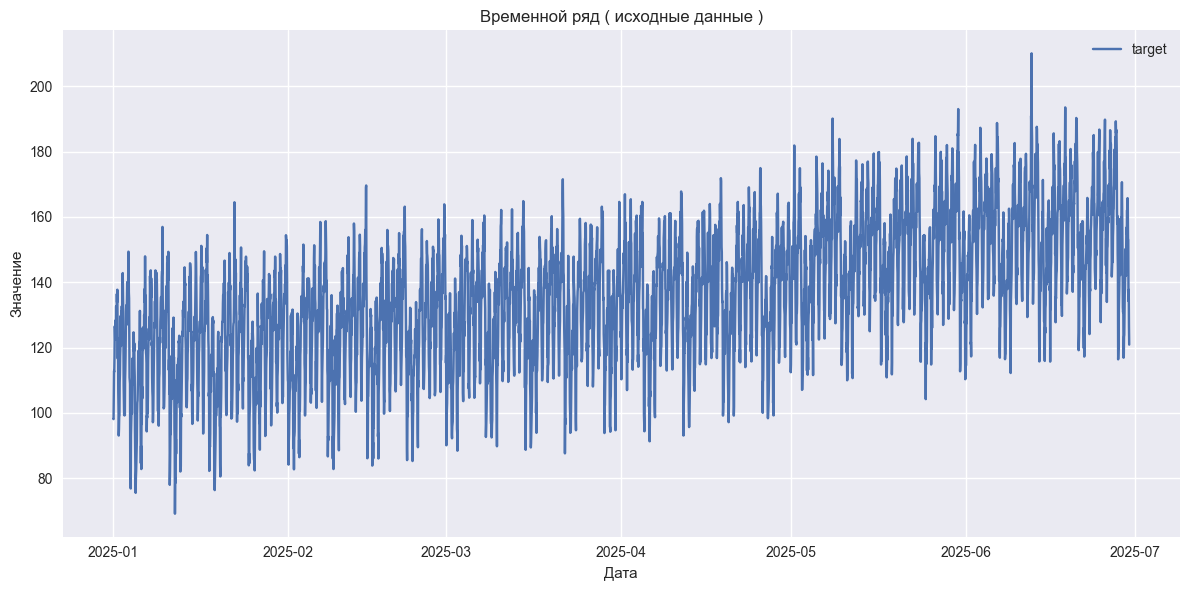

In [50]:
# 2. Данные и первичный анализ

# Проверка наличия файла
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Файл {DATASET_PATH} не найден. Положите S12-hw-dataset.csv в папку с ноутбуком.")

# Загрузка
df = pd.read_csv(DATASET_PATH)

# Приведение даты и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Sanity check
print(f"Размер датасета: {len(df)}")
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"Пропуски:\n{df.isnull().sum()}")

# Проверка целевой колонки
target_col = 'target'
if target_col not in df.columns:
    # Попытка найти похожую колонку, если название отличается
    possible_cols = [c for c in df.columns if 'target' in c.lower() or 'value' in c.lower() or 'y' in c.lower()]
    if possible_cols:
        target_col = possible_cols[0]
        print(f"Колонка 'target' не найдена, используем: {target_col}")
    else:
        raise ValueError("Не найдена целевая колонка. Убедитесь, что есть колонка 'target' или аналог.")

# Базовый график
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df[target_col], label=target_col)
plt.title("Временной ряд ( исходные данные )")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Train: 2592 (2592)
Val:   864 (864)
Test:  864 (864)

Границы split по датам:
  Train: 2025-01-01 00:00:00 → 2025-04-18 23:00:00
  Val:   2025-04-19 00:00:00 → 2025-05-24 23:00:00
  Test:  2025-05-25 00:00:00 → 2025-06-29 23:00:00


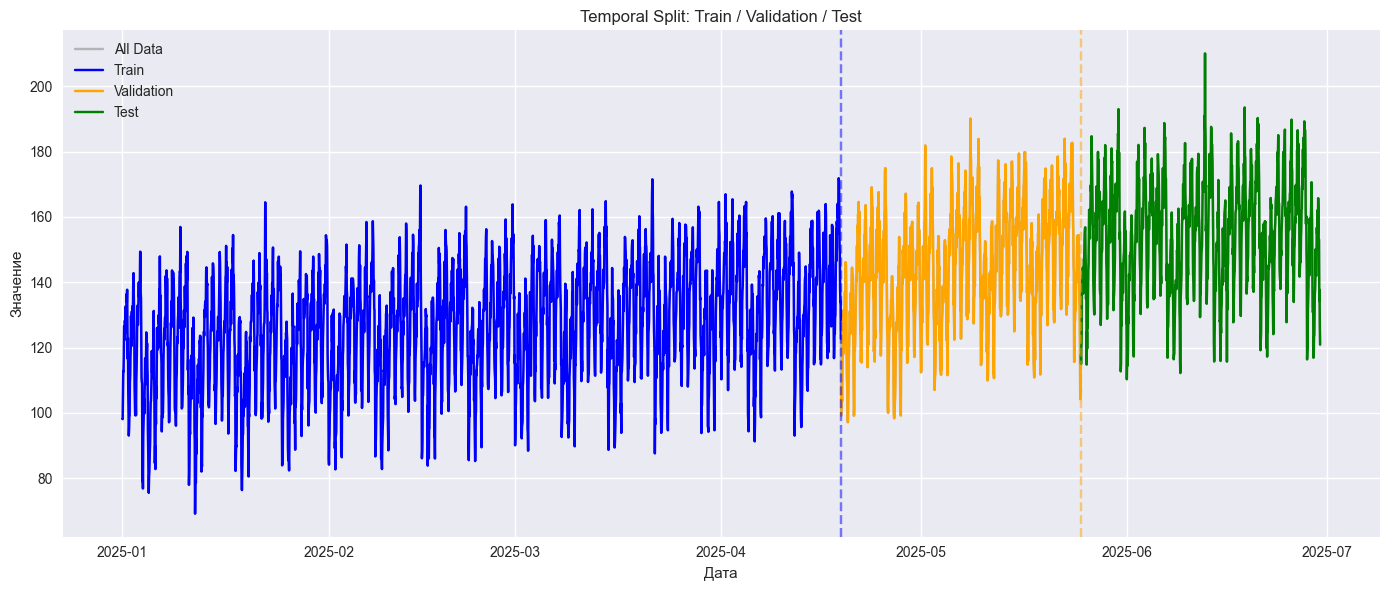

In [51]:
# 3. Корректный temporal split


# Пропорции: 60% Train, 20% Val, 20% Test
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

n = len(df)
train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

# Данные уже отсортированы по дате в Section 2, поэтому iloc сохраняет хронологию
train_df = df.iloc[:train_end].copy()   # Первые 60%
val_df = df.iloc[train_end:val_end].copy()  # Следующие 20%
test_df = df.iloc[val_end:].copy()      # Последние 20%


print(f"Train: {len(train_df)} ({train_end})")
print(f"Val:   {len(val_df)} ({val_end - train_end})")
print(f"Test:  {len(test_df)} ({n - val_end})")

# Явное отображение границ split по датам
print(f"\nГраницы split по датам:")
print(f"  Train: {train_df['date'].min()} → {train_df['date'].max()}")
print(f"  Val:   {val_df['date'].min()} → {val_df['date'].max()}")
print(f"  Test:  {test_df['date'].min()} → {test_df['date'].max()}")

# Визуализация split
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df[target_col], color='gray', alpha=0.5, label='All Data')
plt.plot(train_df['date'], train_df[target_col], color='blue', label='Train')
plt.plot(val_df['date'], val_df[target_col], color='orange', label='Validation')
plt.plot(test_df['date'], test_df[target_col], color='green', label='Test')
plt.axvline(x=train_df['date'].max(), color='blue', linestyle='--', alpha=0.5)
plt.axvline(x=val_df['date'].max(), color='orange', linestyle='--', alpha=0.5)
plt.title("Temporal Split: Train / Validation / Test")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'series_split.png')
plt.show()

### Почему `random split` некорректен для временных рядов?

При случайном разбиении (`random split`) модель может видеть данные из **«будущего»** (относительно прогнозируемой точки) во время обучения. Это приводит к:

1. **Утечке данных (data leakage)** — модель обучается на информации, которая в реальности будет недоступна в момент прогноза.
2. **Завышенной оценке качества** — метрики на валидации становятся нереалистично хорошими, но модель не сможет работать на новых данных.
3. **Нарушению причинно-следственной связи** — временные ряды предполагают, что будущее зависит от прошлого, а не наоборот.

**Вывод:** Для временных рядов обязателен `temporal split` — разбиение по времени без перемешивания, где `train < validation < test` хронологически.

In [52]:
# 4. Признаки для baseline-моделей


def create_features(data, target_col='target'):
    df = data.copy()

    # Лаги
    df['lag_1'] = df[target_col].shift(1)
    df['lag_7'] = df[target_col].shift(7)
    df['lag_14'] = df[target_col].shift(14)

    # Rolling statistics (window=7)
    # ВАЖНО: shift(1) перед rolling, чтобы избежать утечки из будущего
    df['rolling_mean_7'] = df[target_col].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df[target_col].shift(1).rolling(window=7).std()

    # Календарные признаки
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day

    return df

# Применяем ко всему датасету сразу, чтобы лаги считались корректно
df_features = create_features(df, target_col)

# Удаляем строки с NaN (возникшие из-за лагов и rolling)
df_features = df_features.dropna().reset_index(drop=True)

# Пересчитываем индексы сплита после dropna
n_clean = len(df_features)
train_end = int(n_clean * train_ratio)
val_end = int(n_clean * (train_ratio + val_ratio))

train_feat = df_features.iloc[:train_end]
val_feat = df_features.iloc[train_end:val_end]
test_feat = df_features.iloc[val_end:]

# Признаки для моделей
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                'day_of_week', 'month', 'day']

X_train = train_feat[feature_cols].values
y_train = train_feat[target_col].values

X_val = val_feat[feature_cols].values
y_val = val_feat[target_col].values

X_test = test_feat[feature_cols].values
y_test = test_feat[target_col].values

# Масштабирование признаков (x)
# fit только на train, transform на val и test
# Это предотвращает утечку информации через статистику масштабирования (mean, std)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # ← fit + transform на train
X_val_scaled = scaler.transform(X_val)           # ← только transform на val
X_test_scaled = scaler.transform(X_test)         # ← только transform на test

print(f"Scaler fitted on train: mean={scaler.mean_.round(2)}, var={scaler.var_.round(2)}")
print(f"Feature shape: {X_train_scaled.shape}")

Scaler fitted on train: mean=[126.47 126.5  126.38 126.49   9.08   3.01   2.34  14.61], var=[326.79 325.92 324.41 242.98  14.69   3.92   1.13  72.08]
Feature shape: (2583, 8)


In [53]:
# 5. Базовые функции обучения и оценки

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE: избегаем деления на ноль
    mask = y_true != 0
    if np.sum(mask) > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = 0.0
    return mae, rmse, mape

# Хранилище результатов
results = []
best_val_mae = float('inf')
best_exp_id = None

# Хранилище прогнозов для последующего расчёта test-метрик
test_predictions = {}
val_predictions = {}

def log_experiment(exp_id, model_name, y_val_pred, y_val_true, y_test_pred, y_test_true,
                   **kwargs):
    """
    Записывает эксперимент в results БЕЗ тест-метрик.
    Тест-метрики будут рассчитаны отдельно только для лучшей модели.
    """
    global best_val_mae, best_exp_id

    mae_val, rmse_val, mape_val = calculate_metrics(y_val_true, y_val_pred)

    # Обновляем лучшую модель по val_MAE
    if mae_val < best_val_mae:
        best_val_mae = mae_val
        best_exp_id = exp_id

    # Сохраняем прогнозы для последующего расчёта test-метрик
    test_predictions[exp_id] = {'y_pred': y_test_pred, 'y_true': y_test_true}
    val_predictions[exp_id] = {'y_pred': y_val_pred, 'y_true': y_val_true}

    # Записываем эксперимент БЕЗ тест-метрик (они будут None для всех)
    record = {
        'experiment_id': exp_id,
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': SEED,
        'split_summary': f"Train:{len(y_val_true)+len(y_val_pred)},Val:{len(y_val_true)},Test:{len(y_test_true)}",
        'window_size': kwargs.get('window_size', '-'),
        'horizon': 1,
        'model_summary': model_name,
        'features_summary': kwargs.get('features_summary', 'None'),
        'scaler': kwargs.get('scaler_name', '-'),
        'optimizer': kwargs.get('optimizer', '-'),
        'lr': kwargs.get('lr', 0),
        'epochs_trained': kwargs.get('epochs', 0),
        'best_val_mae': mae_val,
        'best_val_rmse': rmse_val,
        'best_val_mape': mape_val,
        # ВАЖНО: Все тест-метрики изначально None
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': kwargs.get('notes', '')
    }
    results.append(record)
    print(f"{exp_id}: Val MAE={mae_val:.4f} (Best: {best_exp_id} = {best_val_mae:.4f})")
    return mae_val


def finalize_test_metrics():
    """
    Вычисляет тест-метрики ТОЛЬКО для лучшей модели после всех экспериментов.
    Это гарантирует, что test используется один раз.
    """
    global results, best_exp_id, test_predictions

    if best_exp_id is None:
        print("лучшая модель ненайдена")
        return

    # Вычисляем тест-метрики только для лучшей модели
    if best_exp_id in test_predictions:
        y_pred = test_predictions[best_exp_id]['y_pred']
        y_true = test_predictions[best_exp_id]['y_true']
        mae_test, rmse_test, mape_test = calculate_metrics(y_true, y_pred)

        # Находим запись лучшей модели в results и обновляем тест-метрики
        for record in results:
            if record['experiment_id'] == best_exp_id:
                record['test_mae'] = mae_test
                record['test_rmse'] = rmse_test
                record['test_mape'] = mape_test
                print(f"Test MAE={mae_test:.4f}, RMSE={rmse_test:.4f}, MAPE={mape_test:.2f}%")
                break


In [54]:
# 6. Эксперименты: Baselines (B1, B2, B3)

# --- B1: Naive Last ---
# Прогноз = последнее известное значение
# Для валидации: последнее значение из train
# Для теста: последнее значение из val
# В рамках данного задания будем считать прогноз на 1 шаг вперед.
# B1 на валидации: предсказываем val[i] используя train[end-1] (глобальный last) или val[i-1] (recursive)?
# Строгий naive-last для одношагового прогноза: y_pred[t] = y_true[t-1].
# Примем упрощение для baseline: прогноз = последнее значение из обучающей выборки (константа)
# ИЛИ прогноз = предыдущее значение ряда (shift).
# В задании сказано "naive-last". Предположим это y_pred = y_{t-1}.
# Реализуем как shift(1) внутри соответствующего набора, но для первого элемента val возьмем последний train.

y_val_pred_b1 = np.zeros_like(y_val)
y_val_pred_b1[0] = y_train[-1]
y_val_pred_b1[1:] = y_val[:-1]

y_test_pred_b1 = np.zeros_like(y_test)
y_test_pred_b1[0] = y_val[-1]
y_test_pred_b1[1:] = y_test[:-1]

log_experiment('B1', 'Naive Last', y_val_pred_b1, y_val, y_test_pred_b1, y_test,
               model_summary="Naive Last (y[t-1])", features_summary="None", notes="Baseline 1")

# --- B2: Moving Average ---
# Прогноз = среднее за последние 7 дней
window_ma = 7
y_val_pred_b2 = np.zeros_like(y_val)
# Для первого элемента берем среднее по концу train
init_mean = y_train[-window_ma:].mean()
y_val_pred_b2[0] = init_mean

# Для остальных - скользящее среднее по реальным значениям
# Но для оценки baseline на валидации мы можем использовать реальные предыдущие значения (recursive evaluation)
# Или использовать предсказания. Для простоты baseline используем реальные предыдущие (Oracle внутри baseline)
# Чтобы было честно, используем реальные данные, доступные на момент прогноза.
full_history = np.concatenate([y_train, y_val])
for i in range(len(y_val)):
    idx = len(y_train) + i
    start_idx = max(0, idx - window_ma)
    y_val_pred_b2[i] = full_history[start_idx:idx].mean()

# Test
y_test_pred_b2 = np.zeros_like(y_test)
full_history_val = np.concatenate([y_train, y_val, y_test])
offset = len(y_train) + len(y_val)
for i in range(len(y_test)):
    idx = offset + i
    start_idx = max(0, idx - window_ma)
    y_test_pred_b2[i] = full_history_val[start_idx:idx].mean()

log_experiment('B2', 'Moving Average', y_val_pred_b2, y_val, y_test_pred_b2, y_test,
               model_summary=f"Moving Average (window={window_ma})", features_summary="None", notes="Baseline 2")

# --- B3: Ridge on Lag Features ---
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

y_val_pred_b3 = ridge_model.predict(X_val_scaled)
y_test_pred_b3 = ridge_model.predict(X_test_scaled)

log_experiment('B3', 'Ridge', y_val_pred_b3, y_val, y_test_pred_b3, y_test,
               model_summary="Ridge Regression", features_summary="Lag, Rolling, Calendar",
               scaler_name="StandardScaler", notes="Baseline 3")

B1: Val MAE=6.4158 (Best: B1 = 6.4158)
B2: Val MAE=12.6790 (Best: B1 = 6.4158)
B3: Val MAE=6.0961 (Best: B3 = 6.0961)


6.09608071293133

Target scaler fitted on train: mean=[126.46], std=[18.08]
Saved best model to artifacts\best_gru.pt
Saved config to artifacts\best_gru_config.json


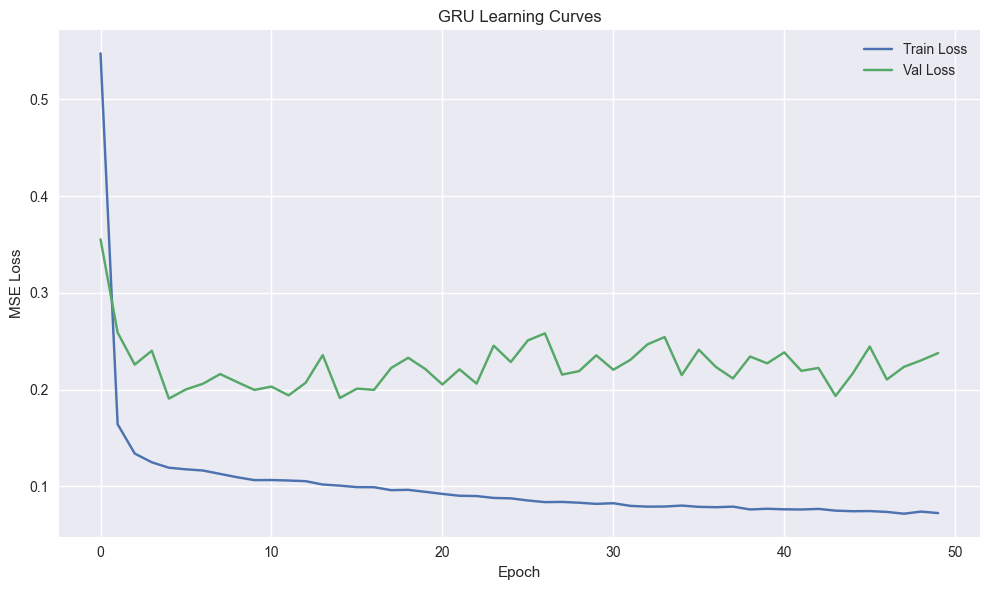

Saved learning curves to artifacts\figures\gru_learning_curves.png
R1 Predictions: val=847, test=848
R1: Val MAE=6.9024 (Best: B3 = 6.0961)


6.902388188205616

In [55]:
# 7. Эксперимент R1: GRU Forecast

# Подготовка оконного представления для GRU
WINDOW_SIZE = 14
HIDDEN_SIZE = 32
BATCH_SIZE = 32
EPOCHS = 50
LR = 0.001

# Масштабирование таргета (y)
# отдельный scaler для таргета, fit только на train
# это предотвращает утечку информации из будущего через статистику таргета

target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()  # ← fit на train
y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1)).flatten()          # ← transform на val
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).flatten()        # ← transform на test

print(f"Target scaler fitted on train: mean={target_scaler.mean_.round(2)}, std={target_scaler.scale_.round(2)}")

# Dataset и DataLoader для последовательностей
# shuffle=True только для train_loader, для val/test — shuffle=False

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, window_size):
        self.X = X
        self.y = y
        self.window_size = window_size

    def __len__(self):
        return len(self.X) - self.window_size

    def __getitem__(self, idx):
        # Последовательность фиксированной длины window_size
        x = self.X[idx : idx + self.window_size]
        # Прогноз следующего значения ряда
        y = self.y[idx + self.window_size]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# Создание датасетов для train/val/test
train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled, WINDOW_SIZE)

# ВАЖНО: shuffle=True только для train, для val/test — shuffle=False
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Модель GRU

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

model = GRUModel(input_size=X_train_scaled.shape[1], hidden_size=HIDDEN_SIZE).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Обучение модели

best_val_loss = float('inf')
best_model_state = None
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

    # Validation
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            epoch_val_loss += loss.item()

    train_losses.append(epoch_train_loss / len(train_loader))
    val_losses.append(epoch_val_loss / len(val_loader))

    # Сохранение лучшей модели по val_loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = model.state_dict()

# Сохранение артефактов

# Сохранение лучшей модели
torch.save(best_model_state, ARTIFACTS_DIR / 'best_gru.pt')
print(f"Saved best model to {ARTIFACTS_DIR / 'best_gru.pt'}")

# Конфиг модели
config = {
    'window_size': WINDOW_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'lr': LR,
    'seed': SEED,
    'input_size': X_train_scaled.shape[1],
    'scaler': 'StandardScaler'
}
with open(ARTIFACTS_DIR / 'best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print(f"Saved config to {ARTIFACTS_DIR / 'best_gru_config.json'}")

# График обучения
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("GRU Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gru_learning_curves.png')
plt.show()
print(f"Saved learning curves to {FIGURES_DIR / 'gru_learning_curves.png'}")

# Оценка на Validation и Test

model.load_state_dict(best_model_state)
model.eval()

# Прогноз на Test
y_test_pred_scaled = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch)
        y_test_pred_scaled.extend(output.cpu().numpy().flatten())

y_test_pred_scaled = np.array(y_test_pred_scaled)
# Обратное масштабирование таргета
y_test_pred_r1 = target_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

# Прогноз на Validation (для заполнения runs.csv)
y_val_pred_scaled = []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch)
        y_val_pred_scaled.extend(output.cpu().numpy().flatten())

y_val_pred_scaled = np.array(y_val_pred_scaled)
y_val_pred_r1 = target_scaler.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()

# Обрезка до длины прогноза (из-за window_size длина меньше оригинала)
len_val_pred = len(y_val_pred_r1)
len_test_pred = len(y_test_pred_r1)

# Корректируем истинные значения под длину прогноза (последние элементы)
y_val_true_r1 = y_val[-len_val_pred:]
y_test_true_r1 = y_test[-len_test_pred:]

print(f"R1 Predictions: val={len(y_val_pred_r1)}, test={len(y_test_pred_r1)}")

# Логирование эксперимента
log_experiment(
    'R1',
    'GRU',
    y_val_pred_r1,
    y_val_true_r1,
    y_test_pred_r1,
    y_test_true_r1,
    window_size=WINDOW_SIZE,
    model_summary=f"GRU (hidden={HIDDEN_SIZE})",
    features_summary="Lag, Rolling, Calendar (scaled)",
    scaler_name="StandardScaler",
    optimizer="Adam",
    lr=LR,
    epochs=EPOCHS,
    notes="Deep Learning",
    is_best_candidate=True
)

Test MAE=6.0673, RMSE=7.7483, MAPE=3.93%
Saved artifacts/runs.csv


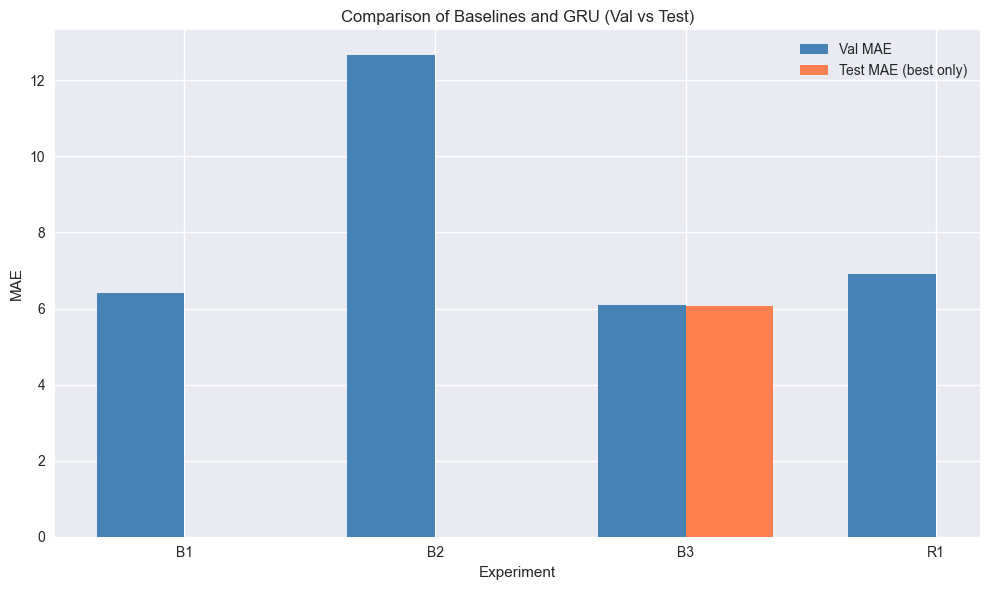

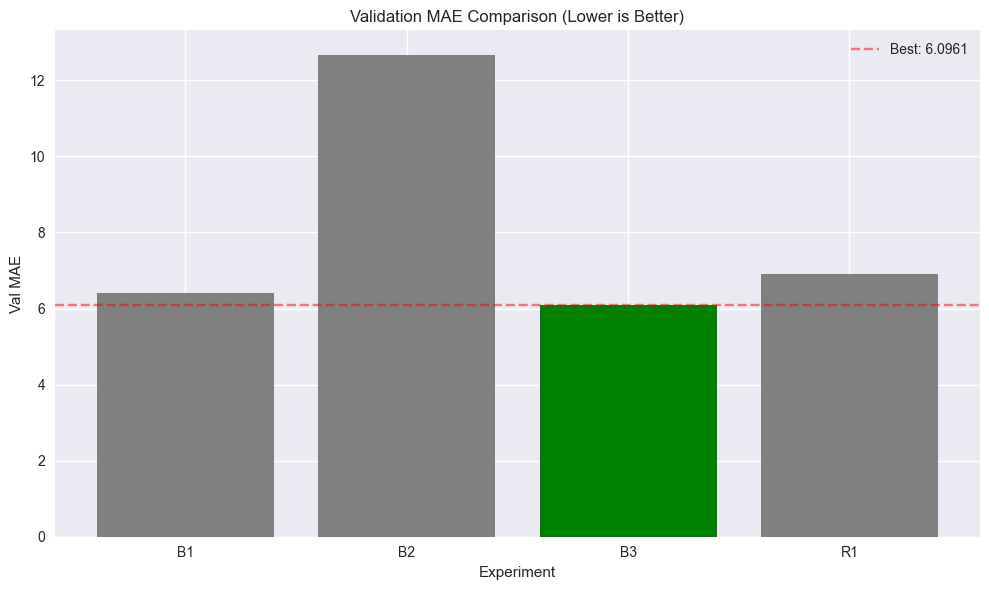

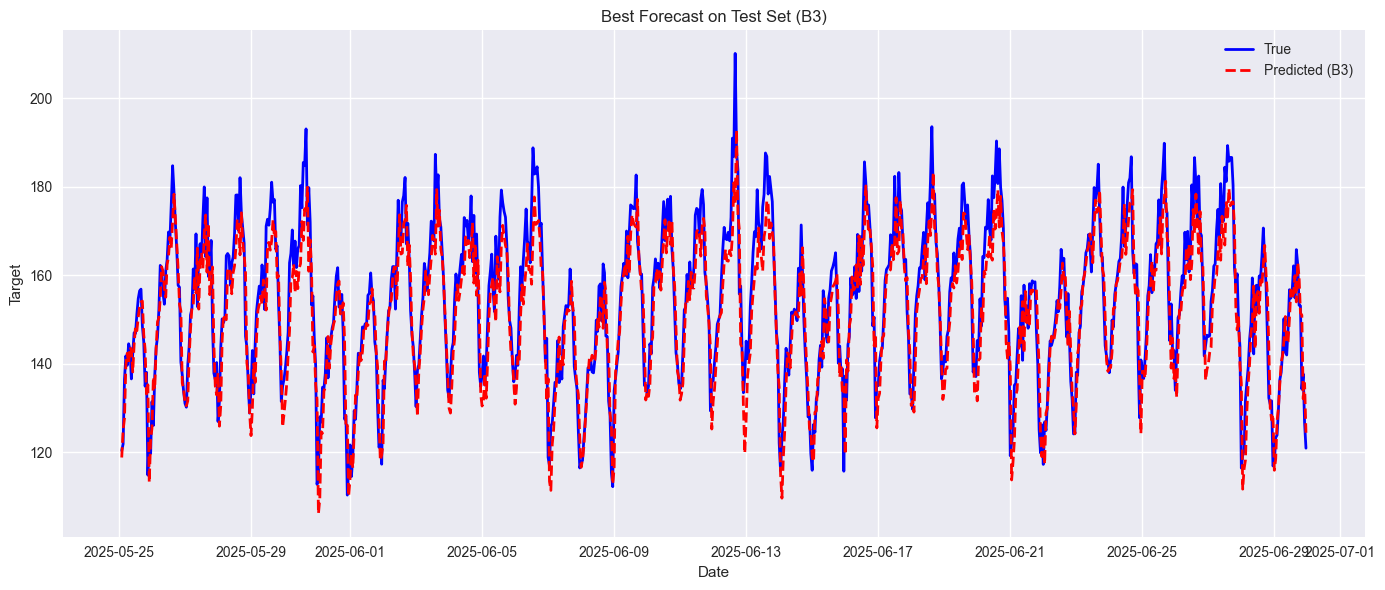


Best Model: B3 with Val MAE: 6.0961
Test MAE: 6.0673


In [56]:
# 8. Финализация артефактов и визуализация

finalize_test_metrics()

# Сохранение runs.csv
runs_df = pd.DataFrame(results)
runs_df.to_csv(ARTIFACTS_DIR / 'runs.csv', index=False)
print("Saved artifacts/runs.csv")

# Сравнение подходов (Bar plot по MAE)
# test-метрики могут быть None для не-лучших моделей, поэтому используем только val
plt.figure(figsize=(10, 6))
exp_ids = [r['experiment_id'] for r in results]
val_maes = [r['best_val_mae'] for r in results]

# Для test MAE берём только валидные значения (не None)
test_maes = [r['test_mae'] if r['test_mae'] is not None else np.nan for r in results]

x = np.arange(len(exp_ids))
width = 0.35

# Plot Val MAE (есть для всех экспериментов)
plt.bar(x - width/2, val_maes, width, label='Val MAE', color='steelblue')

# Plot Test MAE (только для лучшей модели, остальные будут NaN и не отобразятся)
plt.bar(x + width/2, test_maes, width, label='Test MAE (best only)', color='coral',
        tick_label=['' if np.isnan(v) else exp_ids[i] for i, v in enumerate(test_maes)])

plt.xlabel('Experiment')
plt.ylabel('MAE')
plt.title('Comparison of Baselines and GRU (Val vs Test)')
plt.xticks(x, exp_ids)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baselines_compare.png')
plt.show()

# Альтернативный график: только Val MAE для всех экспериментов (более информативно)
plt.figure(figsize=(10, 6))
colors = ['green' if r['experiment_id'] == min(results, key=lambda x: x['best_val_mae'])['experiment_id']
          else 'gray' for r in results]
plt.bar(exp_ids, val_maes, color=colors)
plt.xlabel('Experiment')
plt.ylabel('Val MAE')
plt.title('Validation MAE Comparison (Lower is Better)')
plt.axhline(y=min(val_maes), color='red', linestyle='--', alpha=0.5, label=f'Best: {min(val_maes):.4f}')
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baselines_val_compare.png')
plt.show()

# Финальный прогноз лучшей модели на Test
# Выбираем лучшую по Val MAE
best_res = min(results, key=lambda x: x['best_val_mae'])
best_id = best_res['experiment_id']

# Получаем прогнозы для лучшей модели (из переменных выше)
if best_id == 'B1':
    y_best_pred = y_test_pred_b1
    y_best_true = y_test
elif best_id == 'B2':
    y_best_pred = y_test_pred_b2
    y_best_true = y_test
elif best_id == 'B3':
    y_best_pred = y_test_pred_b3
    y_best_true = y_test
elif best_id == 'R1':
    y_best_pred = y_test_pred_r1
    y_best_true = y_test_true_r1  # Обрезанный тест

# График
plt.figure(figsize=(14, 6))
# Для R1 длина может отличаться, адаптируем даты
if best_id == 'R1':
    plot_dates = test_feat['date'].iloc[-len(y_best_pred):]
else:
    plot_dates = test_feat['date']

plt.plot(plot_dates, y_best_true, label='True', color='blue', linewidth=2)
plt.plot(plot_dates, y_best_pred, label=f'Predicted ({best_id})', color='red', linestyle='--', linewidth=2)
plt.title(f"Best Forecast on Test Set ({best_id})")
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'best_forecast_test.png')
plt.show()

print(f"\n{'='*60}")
print(f"Best Model: {best_id} with Val MAE: {best_res['best_val_mae']:.4f}")
if best_res['test_mae'] is not None:
    print(f"Test MAE: {best_res['test_mae']:.4f}")
else:
    print("Test MAE: Not evaluated (not the best model)")
print(f"{'='*60}")